# V3 Modeling

In [1]:
# ==========
# 0. 패키지
# ==========

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)
from sklearn.impute import SimpleImputer

In [2]:
pd.set_option('display.max_rows', 150)

In [3]:
# ===============
# 1. 데이터 로드
# ===============
DATA_DIR = Path('../Data')
train = pd.read_csv(DATA_DIR / "train_V3.csv")
test = pd.read_csv(DATA_DIR / "test_V3.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

TARGET = "fraud"

X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()
X_test = test.copy()

print("Fraud rate:", y.mean())

train shape: (18000, 117)
test shape : (12000, 116)
Fraud rate: 0.1582222222222222


In [4]:
# ===========
# 4. CV 설정
# ===========
N_SPLITS = 5
RANDOM_STATE = 2542

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [5]:
# ==========================================
# 5. LightGBM 파라미터
# ------------------------------------------
# 불균형 데이터이므로 scale_pos_weight 반영
# ==========================================
pos = (y == 1).sum()
neg = (y == 0).sum()
scale_pos_weight = neg / pos

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.5,
    "n_estimators": 10000,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "verbosity": -1,
}

In [6]:
# ===================
# 5. Fold 반복 학습
# ===================
# 결과 저장 변수
oof_pred = np.zeros(len(X))
oof_pred_label = np.zeros(len(X), dtype=int)
test_pred = np.zeros(len(X_test))

fold_scores = []
feature_importance_list = []
models = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*20} Fold {fold} {'='*20}")

    X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
    y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[valid_idx].copy()

    # 클래스 불균형 반영
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    model = lgb.LGBMClassifier(**params)

    fit_kwargs = dict(
        X=X_train,
        y=y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(stopping_rounds=300),
            lgb.log_evaluation(period=200)
        ]
    )

    model.fit(**fit_kwargs)

    # validation prediction
    threshold = 0.4
    valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    valid_pred_label = (valid_pred_proba >= threshold).astype(int)

    # OOF 저장
    oof_pred[valid_idx] = valid_pred_proba
    oof_pred_label[valid_idx] = valid_pred_label

    # test prediction 저장
    test_pred += model.predict_proba(X_test)[:, 1] / N_SPLITS

    # fold metric
    fold_auc = roc_auc_score(y_valid, valid_pred_proba)
    fold_pr_auc = average_precision_score(y_valid, valid_pred_proba)
    fold_f1 = f1_score(y_valid, valid_pred_label, zero_division=0)

    print(f"Fold {fold} ROC-AUC : {fold_auc:.4f}")
    print(f"Fold {fold} PR-AUC  : {fold_pr_auc:.4f}")
    print(f"Fold {fold} F1      : {fold_f1:.4f}")

    fold_scores.append({
        "fold": fold,
        "roc_auc": fold_auc,
        "pr_auc": fold_pr_auc,
        "f1": fold_f1
    })

    # feature importance 저장
    fold_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_,
        "fold": fold
    })
    feature_importance_list.append(fold_importance)

    models.append(model)


==================== Fold 1 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.678096
Early stopping, best iteration is:
[63]	valid_0's auc: 0.682527
Fold 1 ROC-AUC : 0.6825
Fold 1 PR-AUC  : 0.2834
Fold 1 F1      : 0.3509

==================== Fold 2 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.703848
[400]	valid_0's auc: 0.691357
Early stopping, best iteration is:
[105]	valid_0's auc: 0.709419
Fold 2 ROC-AUC : 0.7094
Fold 2 PR-AUC  : 0.3093
Fold 2 F1      : 0.3631

==================== Fold 3 ====================
Training until validation scores don't improve for 300 rounds
[200]	valid_0's auc: 0.674328
[400]	valid_0's auc: 0.666969
Early stopping, best iteration is:
[100]	valid_0's auc: 0.678583
Fold 3 ROC-AUC : 0.6786
Fold 3 PR-AUC  : 0.2651
Fold 3 F1      : 0.3465

==================== Fold 4 ====================
Training until validation scores don't improve for 300

In [7]:
# ==================
# 6. Fold 결과 요약
# ==================
score_df = pd.DataFrame(fold_scores)

print("\n========== Fold Scores ==========")
print(score_df)

print("\n========== CV Mean Scores ==========")
print(f"Mean ROC-AUC : {score_df['roc_auc'].mean():.4f}")
print(f"Std  ROC-AUC : {score_df['roc_auc'].std():.4f}")
print(f"Mean PR-AUC  : {score_df['pr_auc'].mean():.4f}")
print(f"Mean F1      : {score_df['f1'].mean():.4f}")


========== Fold Scores ==========
   fold   roc_auc    pr_auc        f1
0     1  0.682527  0.283374  0.350862
1     2  0.709419  0.309263  0.363148
2     3  0.678583  0.265137  0.346464
3     4  0.693189  0.302823  0.361111
4     5  0.701476  0.279910  0.362212

========== CV Mean Scores ==========
Mean ROC-AUC : 0.6930
Std  ROC-AUC : 0.0128
Mean PR-AUC  : 0.2881
Mean F1      : 0.3568


In [8]:
# ===========================
# 8. 전체 OOF 기준 성능 평가
# ===========================
oof_auc = roc_auc_score(y, oof_pred)
oof_pr_auc = average_precision_score(y, oof_pred)
oof_f1 = f1_score(y, oof_pred_label, zero_division=0)

print("\n========== OOF Overall Performance ==========")
print(f"OOF ROC-AUC : {oof_auc:.4f}")
print(f"OOF PR-AUC  : {oof_pr_auc:.4f}")
print(f"OOF F1      : {oof_f1:.4f}")

print("\n========== OOF Confusion Matrix ==========")
print(confusion_matrix(y, oof_pred_label))

print("\n========== OOF Classification Report ==========")
print(classification_report(y, oof_pred_label, digits=4, zero_division=0))


========== OOF Overall Performance ==========
OOF ROC-AUC : 0.6889
OOF PR-AUC  : 0.2740
OOF F1      : 0.3565

========== OOF Confusion Matrix ==========
[[9264 5888]
 [ 953 1895]]

========== OOF Classification Report ==========
              precision    recall  f1-score   support

         0.0     0.9067    0.6114    0.7303     15152
         1.0     0.2435    0.6654    0.3565      2848

    accuracy                         0.6199     18000
   macro avg     0.5751    0.6384    0.5434     18000
weighted avg     0.8018    0.6199    0.6712     18000



In [9]:
# ===========================
# 9. 평균 Feature Importance
# ===========================
importance_df = pd.concat(feature_importance_list, axis=0)

mean_importance = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\n========== Mean Feature Importance ==========")
print(mean_importance.head(20))


========== Mean Feature Importance ==========
                         feature  importance
0                  age_of_driver       318.8
1                 vehicle_weight       301.6
2                      liab_prct       299.0
3             zip_fraud_rate_oof       293.0
4                   safty_rating       268.0
5                  annual_income       254.0
6                      claim_day       234.8
7      income_safety_interaction       234.0
8   vehicle_price_per_driver_age       230.4
9               price_per_weight       228.6
10      residual_to_income_ratio       201.2
11       vehicle_to_income_ratio       197.2
12      composite_x_income_ratio       194.2
13      estimated_residual_value       121.4
14                   claim_month       114.4
15            high_education_ind        99.2
16                 vehicle_price        98.6
17                     month_cos        97.0
18            past_num_of_claims        94.2
19            address_change_ind        86.6


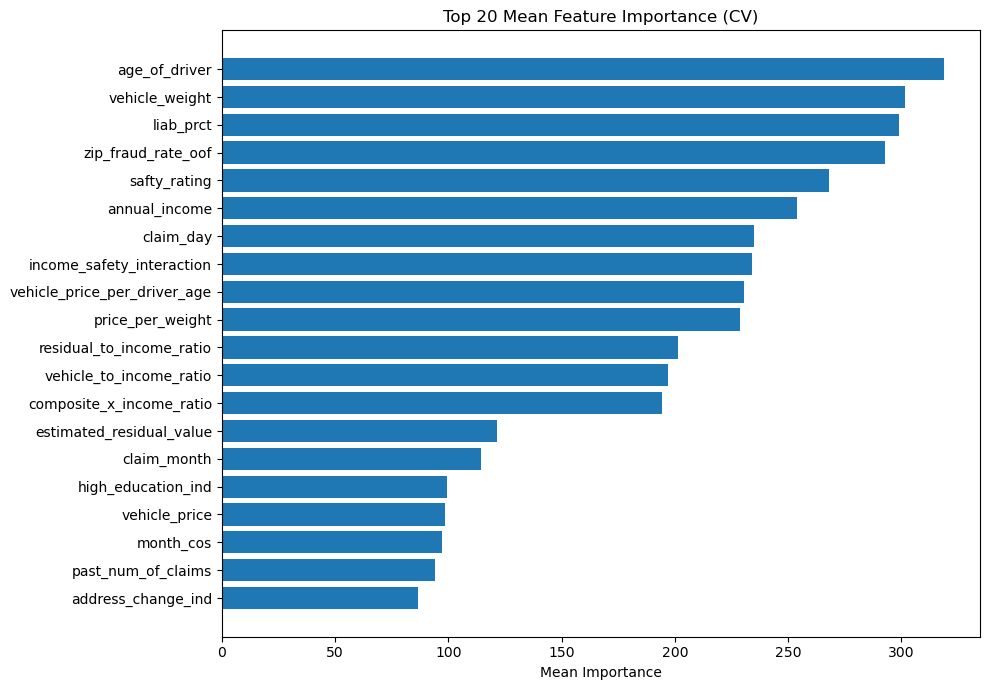

In [10]:
# ==============================
# 10. Feature Importance 시각화
# ==============================
top_k = 20

plt.figure(figsize=(10, 7))
plt.barh(
    mean_importance["feature"].head(top_k)[::-1],
    mean_importance["importance"].head(top_k)[::-1]
)
plt.title("Top 20 Mean Feature Importance (CV)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

In [11]:
# =====================
# 13. Recall@TopK 함수
# =====================
def recall_at_k(y_true, pred_prob, k_ratio=0.1):
    k = int(len(pred_prob) * k_ratio)
    top_idx = np.argsort(pred_prob)[::-1][:k]
    recall = y_true.iloc[top_idx].sum() / y_true.sum()
    return recall

In [12]:
# ======================
# 14. Recall@TopK 출력
# ======================
k_list = [0.01, 0.03, 0.05, 0.10, 0.20, 0.30]

print("\n========== Recall@TopK ==========")
for k in k_list:
    recall_k = recall_at_k(y, oof_pred, k_ratio=k)
    print(f"Recall@Top{int(k*100)}%: {recall_k:.4f}")


========== Recall@TopK ==========
Recall@Top1%: 0.0239
Recall@Top3%: 0.0706
Recall@Top5%: 0.1131
Recall@Top10%: 0.2072
Recall@Top20%: 0.3718
Recall@Top30%: 0.5098


In [13]:
# ========================
# 평균 Feature Importance
# ========================
importance_df = pd.concat(feature_importance_list, axis=0)

mean_importance = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\n========== Mean Feature Importance ==========")
print(mean_importance.head(150))


========== Mean Feature Importance ==========
                                        feature  importance
0                                 age_of_driver       318.8
1                                vehicle_weight       301.6
2                                     liab_prct       299.0
3                            zip_fraud_rate_oof       293.0
4                                  safty_rating       268.0
5                                 annual_income       254.0
6                                     claim_day       234.8
7                     income_safety_interaction       234.0
8                  vehicle_price_per_driver_age       230.4
9                              price_per_weight       228.6
10                     residual_to_income_ratio       201.2
11                      vehicle_to_income_ratio       197.2
12                     composite_x_income_ratio       194.2
13                     estimated_residual_value       121.4
14                                  claim_month      

In [14]:
# =====================
# 11. Threshold Tuning
# =====================
threshold_list = np.arange(0.05, 0.51, 0.05)

result_list = []

print("========== Threshold Tuning ==========")

for th in threshold_list:
    pred_label = (oof_pred >= th).astype(int)

    f1 = f1_score(y, pred_label, zero_division=0)
    precision = precision_score(y, pred_label, zero_division=0)
    recall = recall_score(y, pred_label, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y, pred_label).ravel()

    result_list.append({
        "threshold": th,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

    print(f"\nThreshold = {th:.2f}")
    print(f"F1        : {f1:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"TP={tp} FP={fp} FN={fn} TN={tn}")

result_df = pd.DataFrame(result_list)

========== Threshold Tuning ==========

Threshold = 0.05
F1        : 0.2753
Precision : 0.1596
Recall    : 0.9993
TP=2846 FP=14981 FN=2 TN=171

Threshold = 0.10
F1        : 0.2852
Precision : 0.1664
Recall    : 0.9968
TP=2839 FP=14221 FN=9 TN=931

Threshold = 0.15
F1        : 0.2969
Precision : 0.1749
Recall    : 0.9817
TP=2796 FP=13193 FN=52 TN=1959

Threshold = 0.20
F1        : 0.3080
Precision : 0.1837
Recall    : 0.9540
TP=2717 FP=12077 FN=131 TN=3075

Threshold = 0.25
F1        : 0.3201
Precision : 0.1943
Recall    : 0.9084
TP=2587 FP=10730 FN=261 TN=4422

Threshold = 0.30
F1        : 0.3291
Precision : 0.2049
Recall    : 0.8364
TP=2382 FP=9246 FN=466 TN=5906

Threshold = 0.35
F1        : 0.3461
Precision : 0.2235
Recall    : 0.7669
TP=2184 FP=7588 FN=664 TN=7564

Threshold = 0.40
F1        : 0.3565
Precision : 0.2435
Recall    : 0.6654
TP=1895 FP=5888 FN=953 TN=9264

Threshold = 0.45
F1        : 0.3543
Precision : 0.2642
Recall    : 0.5376
TP=1531 FP=4264 FN=1317 TN=10888

Thresh

In [15]:
# ====================
# 12. Best Threshold
# ====================
best_row = result_df.loc[result_df["f1"].idxmax()]

print("\n========== Best Threshold ==========")
print(best_row)


========== Best Threshold ==========
threshold       0.400000
f1              0.356505
precision       0.243479
recall          0.665379
tp           1895.000000
fp           5888.000000
fn            953.000000
tn           9264.000000
Name: 7, dtype: float64


- Recall@TopK 성능이 부족함
- Recall@TopK 성능 향상을 위한 피처 추가 필요